## Monkeypox differential diagnosis using a Modified Xception Model

Monkeypox images are compared to 'Chickenpox' and 'Measles' skin leasions because of their resemblance to the monkeypox rash and pustules in initial state.
Most of the images provided were augmented images therefore they were used for training but for validation true images were chosen

In [2]:
# Necessary imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing import image_dataset_from_directory
import tensorflow as tf
import os
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, Add
from tensorflow.keras.layers import SeparableConv2D, ReLU
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import GlobalAvgPool2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Conv2D, SeparableConv2D, BatchNormalization, ReLU, MaxPool2D, Add
import warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

print("TF version:", tf.__version__)

TF version: 2.17.1


### Loading and Processing the data

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory("/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Augmented Images/Augmented Images/FOLDS_AUG/fold1_AUG/Train",    
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(299, 299),
    shuffle=True,
    seed=42,                                                   
    validation_split=0.2,
    subset="training",                                                  
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
 )

Found 7518 files belonging to 6 classes.
Using 6015 files for training.


In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory("/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold1/Valid",
  validation_split=None,
  seed=123,
  image_size=(299, 299),
  batch_size=32)

Found 144 files belonging to 6 classes.


In [5]:
class_names = train_ds.class_names
print(class_names)

['Chickenpox', 'Cowpox', 'HFMD', 'Healthy', 'Measles', 'Monkeypox']


### Previewing images

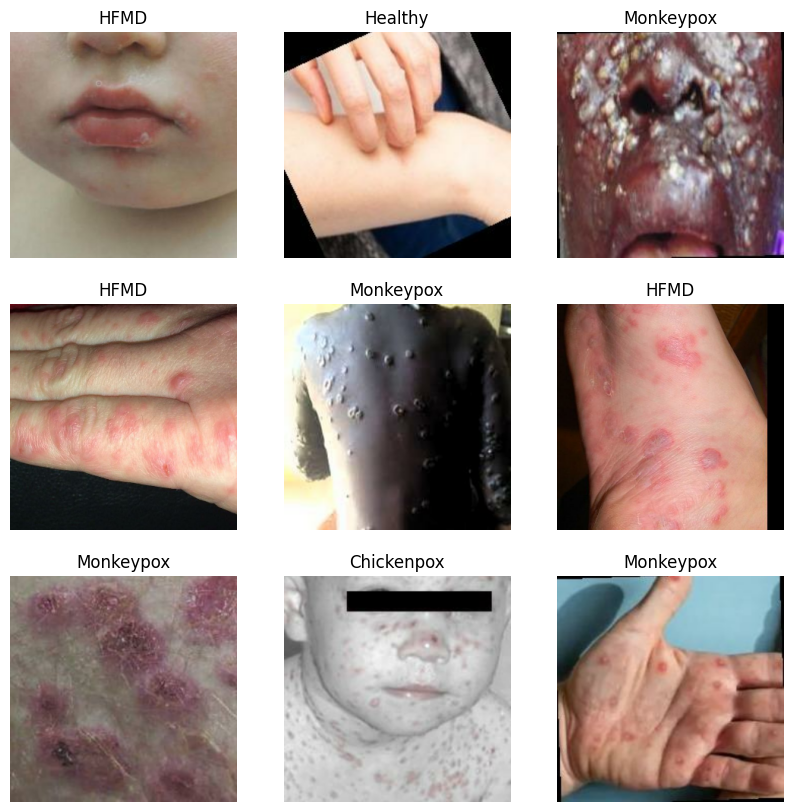

In [8]:
# Preview a batch of images from the dataset
plt.figure(figsize=(10, 10))  # Create a figure with a 10x10 size [[3]]
for images, labels in train_ds.take(1):  # Take one batch of data
    for i in range(9):  # Display the first 9 images
        ax = plt.subplot(3, 3, i + 1)  # Create a 3x3 grid of subplots [[5]]
        plt.imshow(images[i].numpy().astype("uint8"))  # Convert tensor to numpy and display the image [[3]]
        plt.title(class_names[labels[i]])  # Add the class name as the title [[8]]
        plt.axis("off")  # Turn off axis labels for cleaner visualization [[6]]
plt.show()

In [9]:
for image_batch, labels_batch in train_ds:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(32, 299, 299, 3)
(32,)


### Data Normalization

In [10]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
print(np.min(first_image), np.max(first_image))

0.0 0.9992257


### Configuring the data for better performance

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Creating the modified Xception model

In [12]:
from tensorflow.keras.layers import MaxPool2D

In [13]:
# Creating the Conv-Batch Norm block

def conv_bn(x, filters, kernel_size, strides=1):
    x = Conv2D(filters=filters, kernel_size=kernel_size, strides=strides,
              padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    return x   

In [14]:
# Creating separable Conv-batch norm block

def sep_bn(x, filters, kernel_size, strides=1):
    x = SeparableConv2D(filters=filters, kernel_size=kernel_size, strides=strides,
              padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)  
    return x  

In [16]:


def conv_bn(x, filters, kernel_size, strides):
    x = Conv2D(filters, kernel_size=kernel_size, strides=strides, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    return x

def sep_bn(x, filters, kernel_size):
    x = SeparableConv2D(filters, kernel_size=kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    return x

def entry_flow(x):
    x = conv_bn(x, filters=32, kernel_size=3, strides=2)
    x = ReLU()(x)
    x = conv_bn(x, filters=64, kernel_size=3, strides=1)
    x = ReLU()(x)

    # Block 1
    residual = conv_bn(x, filters=128, kernel_size=1, strides=2)
    x = sep_bn(x, filters=128, kernel_size=3)
    x = ReLU()(x)
    x = sep_bn(x, filters=128, kernel_size=3)
    x = MaxPool2D(pool_size=3, strides=2, padding="same")(x)
    x = Add()([x, residual])

    # Block 2
    residual = conv_bn(x, filters=256, kernel_size=1, strides=2)
    x = ReLU()(x)
    x = sep_bn(x, filters=256, kernel_size=3)
    x = ReLU()(x)
    x = sep_bn(x, filters=256, kernel_size=3)
    x = MaxPool2D(pool_size=3, strides=2, padding="same")(x)
    x = Add()([x, residual])

    # Block 3
    residual = conv_bn(x, filters=728, kernel_size=1, strides=2)
    x = ReLU()(x)
    x = sep_bn(x, filters=728, kernel_size=3)
    x = ReLU()(x)
    x = sep_bn(x, filters=728, kernel_size=3)
    x = MaxPool2D(pool_size=3, strides=2, padding="same")(x)
    x = Add()([x, residual])

    return x


In [17]:
def middle_flow(x):
    for _ in range(8):
        residual = x
        x = ReLU()(x)
        x = sep_bn(x, filters=728, kernel_size=3)
        x = ReLU()(x)
        x = sep_bn(x, filters=728, kernel_size=3)
        x = ReLU()(x)
        x = sep_bn(x, filters=728, kernel_size=3)
        x = Add()([residual, x])
    return x

In [18]:
def exit_flow(tensor, num_classes):
    x = ReLU()(tensor)
    x = sep_bn(x, filters=728, kernel_size=3)
    x = ReLU()(x)
    x = sep_bn(x, filters=1024, kernel_size=3)
    x = MaxPool2D(pool_size=3, strides=2, padding="same")(x)

    # Residual path
    residual = conv_bn(tensor, filters=1024, kernel_size=1, strides=2)
    x = Add()([residual, x])

    # Final convolutions
    x = sep_bn(x, filters=1536, kernel_size=3)
    x = ReLU()(x)
    x = sep_bn(x, filters=2048, kernel_size=3)

    # Global Pooling & Classification
    x = GlobalAvgPool2D()(x)
    output = Dense(units=num_classes, activation="softmax")(x)

    return output

In [20]:
input = Input(shape=(299, 299, 3))
x = entry_flow(input)
x = middle_flow(x)
output = exit_flow(x, num_classes=len(class_names))

model = Model(inputs=input, outputs=output)

In [21]:
model =Model(inputs=input, outputs=output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 299, 299, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 150, 150, 32)   │            864 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_35    │ (None, 150, 150, 32)   │            128 │ conv2d_5[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_31 (ReLU)           │ (None, 150, 150, 32)   │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 150, 150, 64)   │         18,432 │ re_lu_31[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_36    │ (None, 150, 150, 64)   │            256 │ conv2d_6[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_32 (ReLU)           │ (None, 150, 150, 64)   │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_30       │ (None, 150, 150, 128)  │          8,768 │ re_lu_32[0][0]         │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_38    │ (None, 150, 150, 128)  │            512 │ separable_conv2d_30[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_33 (ReLU)           │ (None, 150, 150, 128)  │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_31       │ (None, 150, 150, 128)  │         17,536 │ re_lu_33[0][0]         │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_39    │ (None, 150, 150, 128)  │            512 │ separable_conv2d_31[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 75, 75, 128)    │          8,192 │ re_lu_32[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 75, 75, 128)    │              0 │ batch_normalization_3… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_37    │ (None, 75, 75, 128)    │            512 │ conv2d_7[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 20,873,774 (79.63 MB)

 Trainable params: 20,819,246 (79.42 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [23]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),  # or from_logits=False
    metrics=['accuracy']
)

In [24]:
epochs=50
history = model.fit(
  train_ds,
  validation_data=val_ds,
    epochs=epochs,
   )          
  

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 181s 670ms/step - accuracy: 0.3831 - loss: 1.8279 - val_accuracy: 0.3819 - val_loss: 1.6216
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 431ms/step - accuracy: 0.5152 - loss: 1.2831 - val_accuracy: 0.3819 - val_loss: 1.6535
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 431ms/step - accuracy: 0.5873 - loss: 1.0860 - val_accuracy: 0.3889 - val_loss: 2.9511
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 431ms/step - accuracy: 0.6827 - loss: 0.8404 - val_accuracy: 0.4583 - val_loss: 3.0577
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 431ms/step - accuracy: 0.7860 - loss: 0.5932 - val_accuracy: 0.5486 - val_loss: 2.2261
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 431ms/step - accuracy: 0.8447 - loss: 0.4345 - val_accuracy: 0.4514 - val_loss: 2.4842
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 431ms/step - accuracy: 0.8831 - loss: 0.3181 - val_accuracy: 0.3194 - val_loss: 4.5418
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 431ms/step - accuracy: 0.9220 - loss: 

In [29]:
from sklearn.metrics import classification_report, f1_score

# Predict on validation dataset
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Print report
print(classification_report(y_true, y_pred, target_names=class_names))

# Get macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

  Chickenpox       0.38      0.38      0.38        16
      Cowpox       0.80      0.40      0.53        10
        HFMD       0.56      0.62      0.59        29
     Healthy       0.83      0.68      0.75        22
     Measles       0.73      0.67      0.70        12
   Monkeypox       0.60      0.67      0.63        55

    accuracy                           0.61       144
   macro avg       0.65      0.57      0.60       144
weighted avg       0.63      0.61      0.61       144

Macro F1 Score: 0.5961
